In [1]:
import pandas as pd

f = "train.csv"
df = pd.read_csv(f)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)
df.head()

Shape: (2000, 21)

Columns: ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']

Data types:
 battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [2]:
# ── Step 1: Exploration + descriptive statistics ──────────────
print("=== Shape ===")
print(df.shape, "→ 2000 phones, 20 features + 1 target\n")

# Identify feature groups
binary_cols = [c for c in df.columns
               if df[c].dropna().isin([0, 1]).all() and c != "price_range"]
continuous_cols = [c for c in df.columns
                   if c not in binary_cols + ["price_range"]]

print("Binary (0/1) features:", binary_cols)
print("\nContinuous features:", continuous_cols)
print("\nTarget: price_range, classes =", sorted(df["price_range"].unique()))

print("\n=== Null values ===")
print(df.isnull().sum().sum(), "total nulls")

print("\n=== Target balance ===")
print(df["price_range"].value_counts().sort_index())

print("\n=== Descriptive statistics (continuous features) ===")
df[continuous_cols].describe().round(2)

=== Shape ===
(2000, 21) → 2000 phones, 20 features + 1 target

Binary (0/1) features: ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

Continuous features: ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']

Target: price_range, classes = [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

=== Null values ===
0 total nulls

=== Target balance ===
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

=== Descriptive statistics (continuous features) ===


,battery_power,clock_speed,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1238.52,1.52,4.31,32.05,0.50,140.25,4.52,9.92,645.11,1251.52,2124.21,12.31,5.77,11.01
std,439.42,0.82,4.34,18.15,0.29,35.40,2.29,6.06,443.78,432.20,1084.73,4.21,4.36,5.46
min,501.00,0.50,0.00,2.00,0.10,80.00,1.00,0.00,0.00,500.00,256.00,5.00,0.00,2.00
25%,851.75,0.70,1.00,16.00,0.20,109.00,3.00,5.00,282.75,874.75,1207.50,9.00,2.00,6.00
50%,1226.00,1.50,3.00,32.00,0.50,141.00,4.00,10.00,564.00,1247.00,2146.50,12.00,5.00,11.00
75%,1615.25,2.20,7.00,48.00,0.80,170.00,7.00,15.00,947.25,1633.00,3064.50,16.00,9.00,16.00
max,1998.00,3.00,19.00,64.00,1.00,200.00,8.00,20.00,1960.00,1998.00,3998.00,19.00,18.00,20.00


In [3]:
# ── Step 2: Cleaning + preprocessing ──────────────────────────
import numpy as np

data = df.copy()

# 1) Confirm nulls (we saw 0, but verify explicitly)
print("Null values:", data.isnull().sum().sum())

# 2) Handle disguised-missing zeros in columns where 0 is impossible
#    px_height = 0 and sc_w = 0 are not physically valid.
for col in ["px_height", "sc_w"]:
    n_zeros = (data[col] == 0).sum()
    print(f"{col}: {n_zeros} zero values → replacing with median")
    data[col] = data[col].replace(0, np.nan)
    data[col] = data[col].fillna(data[col].median())

# 3) Categorical → numerical
#    The binary flags are already 0/1 (no work needed).
#    There are no text columns, so nothing to encode.
#    price_range is already an integer-coded ordinal target.
print("\nAll features already numeric — no text encoding required.")
print("Binary flags already 0/1:", binary_cols)

# 4) Confirm the fix
print("\n=== After cleaning: min values for the two fixed columns ===")
print(data[["px_height", "sc_w"]].min())

print("\nFinal shape:", data.shape)
data.head()

Null values: 0
px_height: 2 zero values → replacing with median
sc_w: 180 zero values → replacing with median

All features already numeric — no text encoding required.
Binary flags already 0/1: ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

=== After cleaning: min values for the two fixed columns ===
px_height    1.0
sc_w         1.0
dtype: float64

Final shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20.0,756,2549,9,7.0,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905.0,1988,2631,17,3.0,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263.0,1716,2603,11,2.0,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216.0,1786,2769,16,8.0,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208.0,1212,1411,8,2.0,15,1,1,0,1


In [4]:
# ── Step 3a: Central tendency, variability, shape ─────────────
import numpy as np
from scipy import stats

rows = []
for col in continuous_cols:
    x = data[col].values
    rows.append({
        "feature":  col,
        "mean":     np.mean(x),
        "median":   np.median(x),
        "mode":     stats.mode(x, keepdims=True)[0][0],
        "range":    np.ptp(x),                 # max - min
        "variance": np.var(x, ddof=1),
        "std":      np.std(x, ddof=1),
        "skew":     stats.skew(x),
        "kurtosis": stats.kurtosis(x),         # excess kurtosis (normal=0)
    })

stat_table = pd.DataFrame(rows).set_index("feature").round(2)
pd.set_option("display.width", 200)
print(stat_table)

                  mean  median    mode   range    variance      std  skew  kurtosis
feature                                                                            
battery_power  1238.52  1226.0   618.0  1497.0   193088.36   439.42  0.03     -1.22
clock_speed       1.52     1.5     0.5     2.5        0.67     0.82  0.18     -1.32
fc                4.31     3.0     0.0    19.0       18.85     4.34  1.02      0.27
int_memory       32.05    32.0    27.0    62.0      329.27    18.15  0.06     -1.22
m_dep             0.50     0.5     0.1     0.9        0.08     0.29  0.09     -1.27
mobile_wt       140.25   141.0   182.0   120.0     1253.14    35.40  0.01     -1.21
n_cores           4.52     4.0     4.0     7.0        5.23     2.29  0.00     -1.23
pc                9.92    10.0    10.0    20.0       36.78     6.06  0.02     -1.17
px_height       645.67   565.5   347.0  1959.0   196531.06   443.32  0.67     -0.31
px_width       1251.52  1247.0   874.0  1498.0   186796.36   432.20  0.01   

In [5]:
# ── Step 3b: Hypothesis testing across price ranges ───────────
from scipy import stats

# Compare the lowest (0) vs highest (3) price range for each feature
print("=== t-tests: price_range 0 (low) vs 3 (very high) ===\n")
print(f"{'feature':<15}{'mean(0)':>10}{'mean(3)':>10}{'t-stat':>10}{'p-value':>12}")
print("-" * 57)

for col in continuous_cols:
    g0 = data.loc[data["price_range"] == 0, col]
    g3 = data.loc[data["price_range"] == 3, col]
    t, p = stats.ttest_ind(g0, g3, equal_var=False)   # Welch's
    flag = " ***" if p < 0.001 else (" *" if p < 0.05 else "")
    print(f"{col:<15}{g0.mean():>10.1f}{g3.mean():>10.1f}{t:>10.2f}{p:>12.2e}{flag}")

# ANOVA: does the feature differ across ALL four price ranges?
print("\n=== One-way ANOVA across all 4 price ranges ===\n")
print(f"{'feature':<15}{'F-stat':>12}{'p-value':>14}")
print("-" * 41)
for col in continuous_cols:
    groups = [data.loc[data["price_range"] == k, col] for k in range(4)]
    f, p = stats.f_oneway(*groups)
    flag = " ***" if p < 0.001 else (" *" if p < 0.05 else "")
    print(f"{col:<15}{f:>12.2f}{p:>14.2e}{flag}")

=== t-tests: price_range 0 (low) vs 3 (very high) ===

feature           mean(0)   mean(3)    t-stat     p-value
---------------------------------------------------------
battery_power      1116.9    1380.0    -10.07    8.45e-23 ***
clock_speed           1.6       1.5      0.57    5.67e-01
fc                    4.1       4.3     -0.86    3.89e-01
int_memory           31.2      34.0     -2.46    1.41e-02 *
m_dep                 0.5       0.5     -0.64    5.20e-01
mobile_wt           140.6     136.3      1.88    6.08e-02
n_cores               4.6       4.5      0.68    4.97e-01
pc                    9.6      10.2     -1.50    1.35e-01
px_height           536.4     746.0     -7.68    3.88e-14 ***
px_width           1150.3    1369.8     -8.27    4.37e-16 ***
ram                 785.3    3449.2   -111.37    0.00e+00 ***
sc_h                 12.3      12.7     -1.34    1.79e-01
sc_w                  6.3       6.6     -1.27    2.05e-01
talk_time            10.6      11.1     -1.42    1.57e-01

In [6]:
# ── Step 3c: Feature–target correlations ──────────────────────
from scipy import stats

# price_range is ordinal (0<1<2<3), so Spearman is the most appropriate,
# but we'll report Pearson too for comparison.
print("=== Correlation of each feature with price_range ===\n")
print(f"{'feature':<15}{'Pearson r':>12}{'p-value':>12}{'Spearman':>12}")
print("-" * 51)

results = []
for col in continuous_cols + binary_cols:
    pear_r, pear_p = stats.pearsonr(data[col], data["price_range"])
    spear_r, _ = stats.spearmanr(data[col], data["price_range"])
    results.append((col, pear_r, pear_p, spear_r))

# Sort by absolute Pearson correlation, strongest first
for col, pr, pp, sr in sorted(results, key=lambda t: abs(t[1]), reverse=True):
    flag = " ***" if pp < 0.001 else (" *" if pp < 0.05 else "")
    print(f"{col:<15}{pr:>12.3f}{pp:>12.2e}{sr:>12.3f}{flag}")

=== Correlation of each feature with price_range ===

feature           Pearson r     p-value    Spearman
---------------------------------------------------
ram                   0.917    0.00e+00       0.917 ***
battery_power         0.201    1.26e-19       0.200 ***
px_width              0.166    8.48e-14       0.165 ***
px_height             0.150    1.78e-11       0.133 ***
int_memory            0.044    4.69e-02       0.044 *
pc                    0.034    1.33e-01       0.033
sc_w                  0.031    1.65e-01       0.012
touch_screen         -0.030    1.74e-01      -0.030
mobile_wt            -0.030    1.76e-01      -0.030
three_g               0.024    2.91e-01       0.024
sc_h                  0.023    3.04e-01       0.024
fc                    0.022    3.25e-01       0.024
talk_time             0.022    3.29e-01       0.022
blue                  0.021    3.58e-01       0.021
wifi                  0.019    4.01e-01       0.019
dual_sim              0.017    4.36e-01     

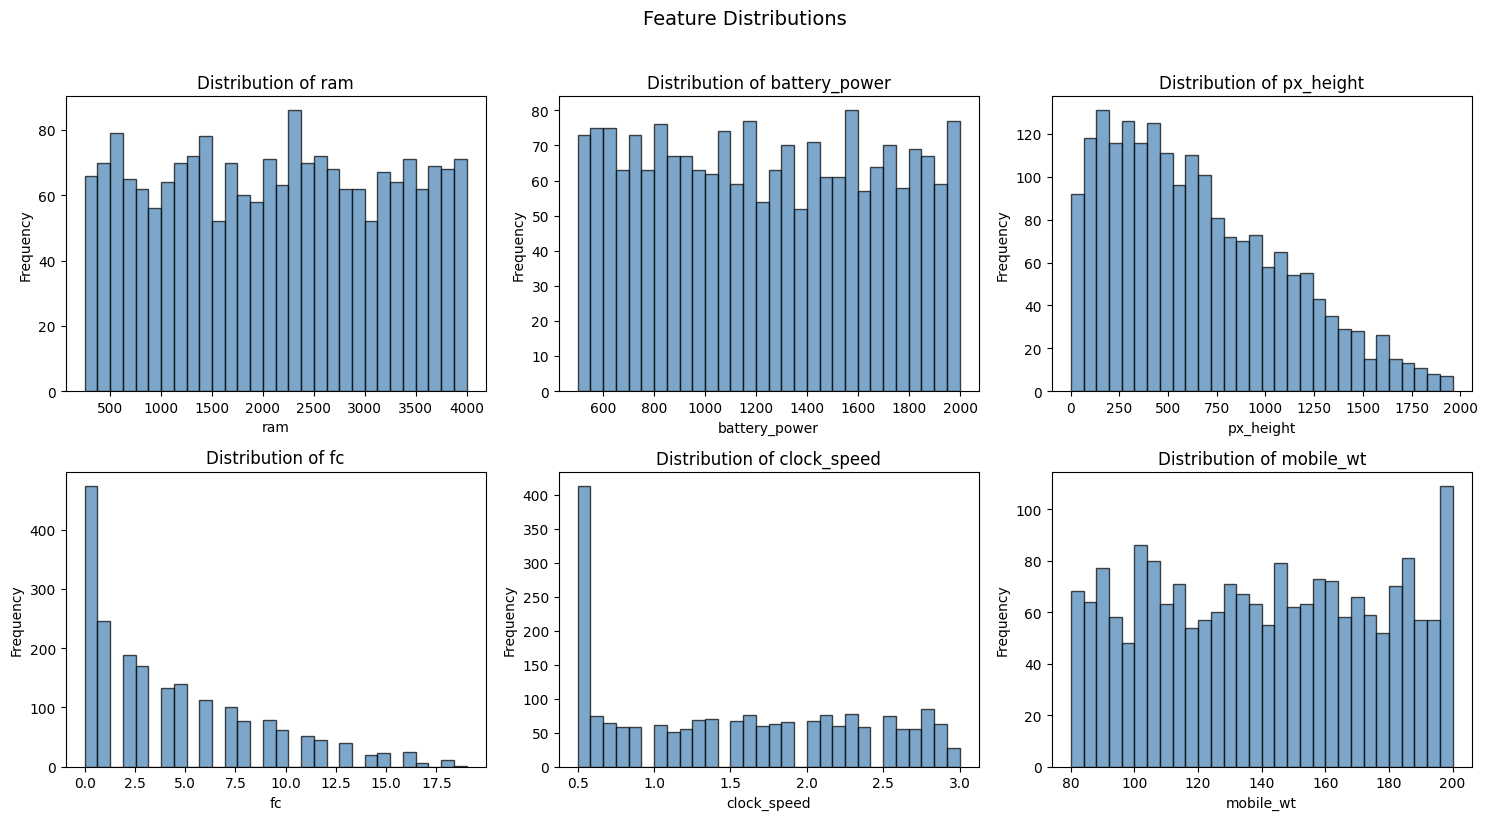

In [7]:
# ── Step 4a: Histograms of key features ───────────────────────
import matplotlib.pyplot as plt

key_feats = ["ram", "battery_power", "px_height", "fc", "clock_speed", "mobile_wt"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, key_feats):
    ax.hist(data[col], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col); ax.set_ylabel("Frequency")

plt.suptitle("Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

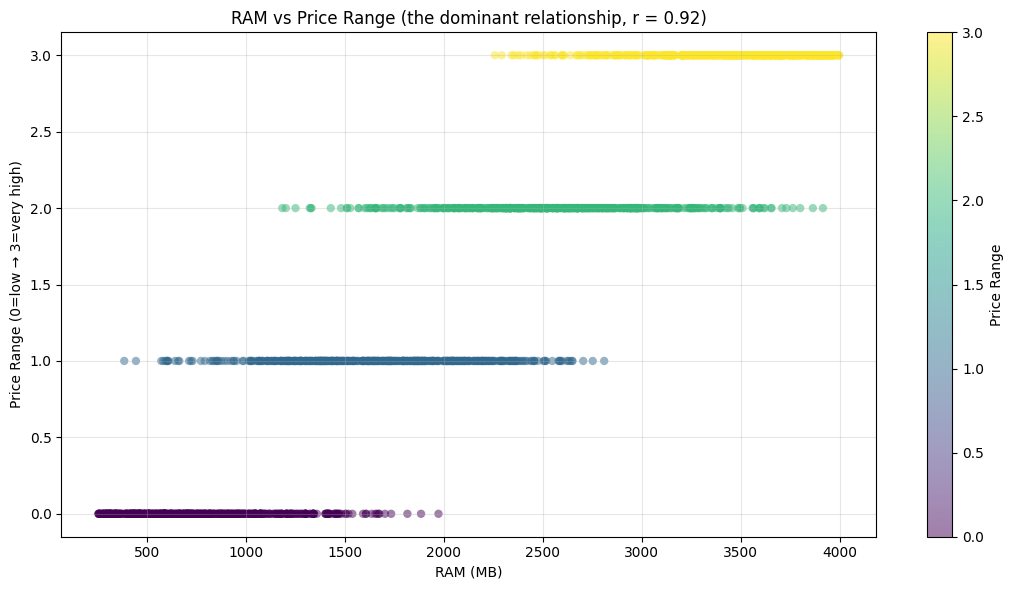

In [8]:
# ── Step 4b: Scatter — RAM vs price (the key relationship) ────
plt.figure(figsize=(11, 6))
scatter = plt.scatter(data["ram"], data["price_range"],
                      c=data["price_range"], cmap="viridis",
                      alpha=0.5, edgecolors="none")
plt.title("RAM vs Price Range (the dominant relationship, r = 0.92)")
plt.xlabel("RAM (MB)"); plt.ylabel("Price Range (0=low → 3=very high)")
plt.colorbar(scatter, label="Price Range")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

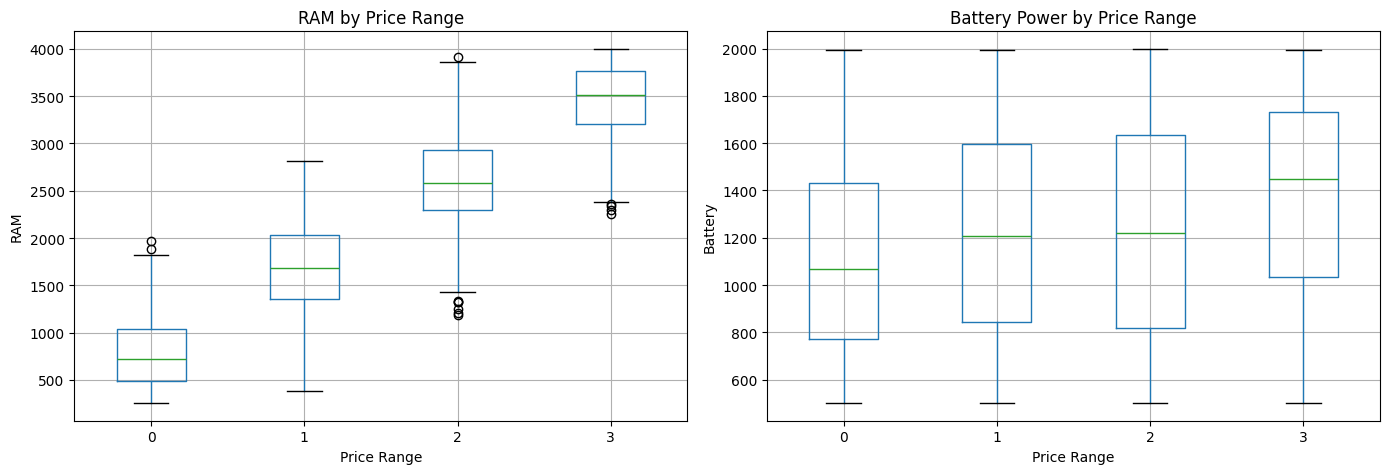

In [9]:
# ── Step 4c: Box plots — how RAM & battery split by price ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data.boxplot(column="ram", by="price_range", ax=axes[0])
axes[0].set_title("RAM by Price Range"); axes[0].set_xlabel("Price Range"); axes[0].set_ylabel("RAM")

data.boxplot(column="battery_power", by="price_range", ax=axes[1])
axes[1].set_title("Battery Power by Price Range"); axes[1].set_xlabel("Price Range"); axes[1].set_ylabel("Battery")

plt.suptitle("")  # remove pandas' auto title
plt.tight_layout(); plt.show()

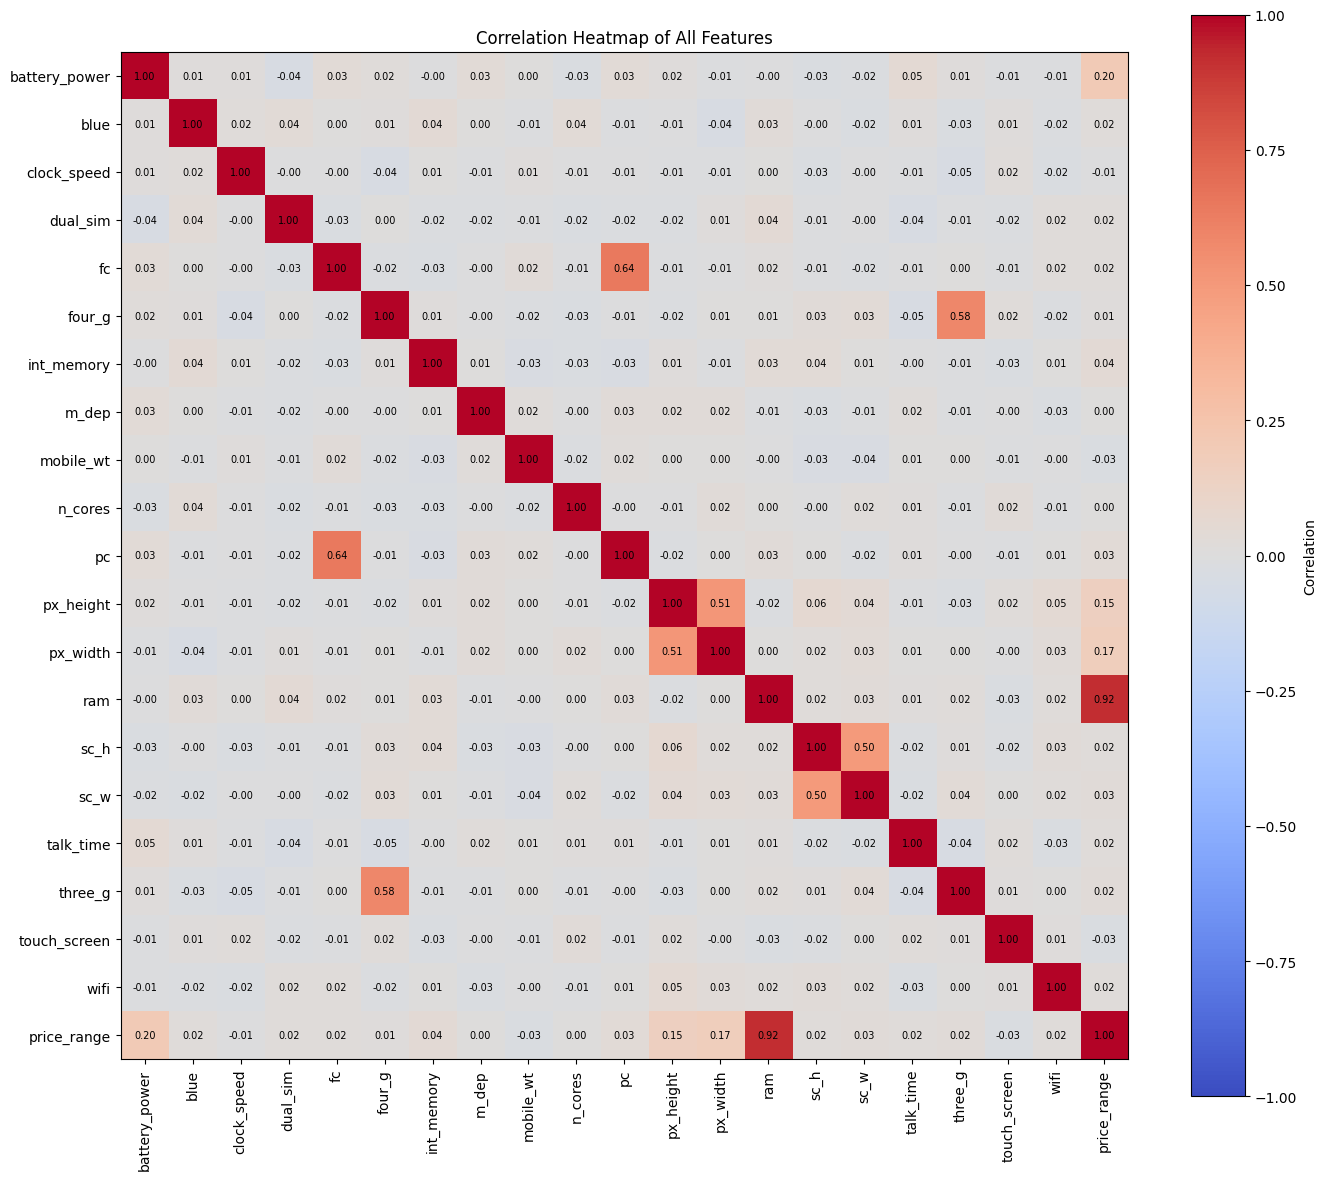

In [10]:
# ── Step 4d: Correlation heatmap ──────────────────────────────
import numpy as np

corr = data.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Annotate each cell with its value
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=7)

plt.colorbar(im, label="Correlation")
plt.title("Correlation Heatmap of All Features")
plt.tight_layout(); plt.show()

In [11]:
# ── Step 5: Conclusion & insight synthesis ────────────────────
print("="*60)
print("MOBILE PRICE CLASSIFICATION — CONCLUSIONS")
print("="*60)
print("""
DATASET
  • 2,000 phones, 20 features, balanced target (500 per class)
  • No missing values; 180 disguised zeros in sc_w cleaned via median

KEY DETERMINANT OF PRICE
  • RAM is overwhelmingly dominant:
      - correlation with price = 0.92
      - t-stat (low vs high tier) = -111  (next largest ~ -10)
      - ANOVA F = 3,520           (next largest ~ 32)
      - mean RAM rises 785 → 3,449 MB from cheapest to priciest

SECONDARY DRIVERS (weak but statistically significant)
  • battery_power (r = 0.20)
  • px_width      (r = 0.17)
  • px_height     (r = 0.15)
  → screen resolution and battery add modest signal

NON-FACTORS (no significant link to price)
  • clock_speed, camera MP (fc/pc), screen size (sc_h/sc_w),
    talk_time, n_cores, internal memory
  • ALL binary features: 4G, 3G, wifi, bluetooth, dual-sim,
    touchscreen — none correlate with price

DISTRIBUTION NOTES
  • Most features are ~uniform (kurtosis ≈ -1.2), not normal
  • fc and px_height are right-skewed (many low values, few high)

UNEXPECTED FINDING
  • Connectivity & convenience features (4G, wifi, touchscreen)
    have essentially ZERO relationship with price in this dataset.
    Price is driven by core hardware capacity (RAM above all),
    not by feature checkboxes.
""")

MOBILE PRICE CLASSIFICATION — CONCLUSIONS

DATASET
  • 2,000 phones, 20 features, balanced target (500 per class)
  • No missing values; 180 disguised zeros in sc_w cleaned via median

KEY DETERMINANT OF PRICE
  • RAM is overwhelmingly dominant:
      - correlation with price = 0.92
      - t-stat (low vs high tier) = -111  (next largest ~ -10)
      - ANOVA F = 3,520           (next largest ~ 32)
      - mean RAM rises 785 → 3,449 MB from cheapest to priciest

SECONDARY DRIVERS (weak but statistically significant)
  • battery_power (r = 0.20)
  • px_width      (r = 0.17)
  • px_height     (r = 0.15)
  → screen resolution and battery add modest signal

NON-FACTORS (no significant link to price)
  • clock_speed, camera MP (fc/pc), screen size (sc_h/sc_w),
    talk_time, n_cores, internal memory
  • ALL binary features: 4G, 3G, wifi, bluetooth, dual-sim,
    touchscreen — none correlate with price

DISTRIBUTION NOTES
  • Most features are ~uniform (kurtosis ≈ -1.2), not normal
  • fc and